# Delaunay Triangulation

The matplotlib.tri module provides tools for working with unstructured triangular grids. It is primarily used when data points are not on a regular grid.

In [6]:
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import numpy as np

## 1. Random Delaunary Triangulation

If you only have points, Matplotlib can automatically create a Delaunay triangulation. You can use the Triplot Demo as a primary reference.

Creating a Triangulation without specifying the triangles results in the Delaunay triangulation of the points.


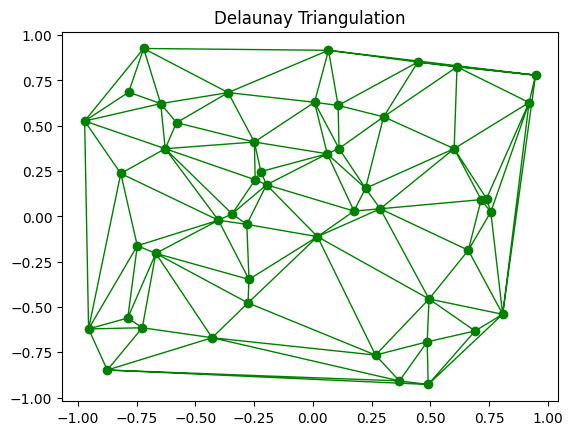

In [14]:
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import numpy as np

# Create random points
n_points = 50
x = np.random.uniform(-1, 1, n_points)
y = np.random.uniform(-1, 1, n_points)

# Create triangulation object (Delaunay)
triang = tri.Triangulation(x, y)

# Plot the triangular grid
plt.triplot(triang, 'go-', lw=1)
plt.title('Delaunay Triangulation')
plt.show()

## 2. Manual Triangulation (User-Specified)

You can explicitly define which points form each triangle by passing an index array to the Triangulation class. 

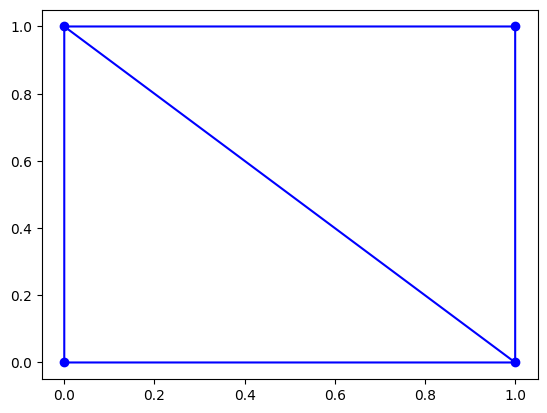

In [15]:
# Points: (0,0), (1,0), (0,1), (1,1)
x = np.array([0, 1, 0, 1])
y = np.array([0, 0, 1, 1])

# Define triangles by indices of the points above (counter-clockwise)
triangles = [[0, 1, 2], [1, 2, 3]]
triang_custom = tri.Triangulation(x, y, triangles=triangles)

plt.triplot(triang_custom, 'bo-')
plt.show()

## 3. Interpolation and Contouring
The matplotlib.tri module includes interpolators like LinearTriInterpolator and CubicTriInterpolator **to estimate values between known points**. The Triinterp Demo provides a comprehensive example of these methods.

* tricontourf: Creates filled contours on the triangular grid.
* tripcolor: Creates a pseudocolor plot for unstructured grids.
* plot_trisurf: Plots a 3D surface using the triangulation.

## Triinterp Demo
Interpolation from triangular grid to quad grid.

https://matplotlib.org/stable/gallery/images_contours_and_fields/triinterp_demo.html

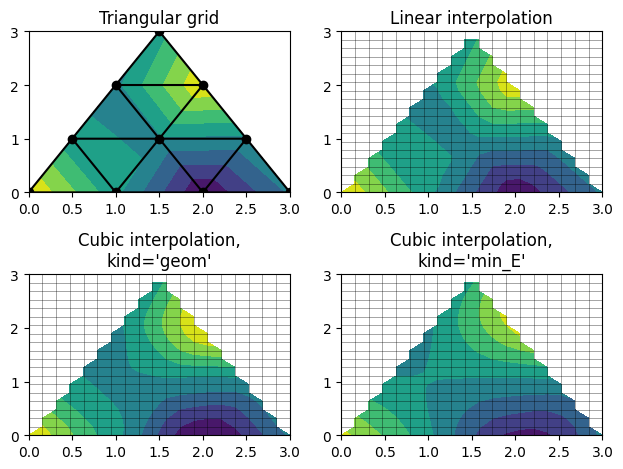

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.tri as mtri

# Create triangulation.
x = np.asarray([0, 1, 2, 3, 0.5, 1.5, 2.5, 1, 2, 1.5])
y = np.asarray([0, 0, 0, 0, 1.0, 1.0, 1.0, 2, 2, 3.0])
triangles = [[0, 1, 4], [1, 2, 5], [2, 3, 6], [1, 5, 4], [2, 6, 5], [4, 5, 7],
             [5, 6, 8], [5, 8, 7], [7, 8, 9]]
triang = mtri.Triangulation(x, y, triangles)

# Interpolate to regularly-spaced quad grid.
z = np.cos(1.5 * x) * np.cos(1.5 * y)
xi, yi = np.meshgrid(np.linspace(0, 3, 20), np.linspace(0, 3, 20))

interp_lin = mtri.LinearTriInterpolator(triang, z)
zi_lin = interp_lin(xi, yi)

interp_cubic_geom = mtri.CubicTriInterpolator(triang, z, kind='geom')
zi_cubic_geom = interp_cubic_geom(xi, yi)

interp_cubic_min_E = mtri.CubicTriInterpolator(triang, z, kind='min_E')
zi_cubic_min_E = interp_cubic_min_E(xi, yi)

# Set up the figure
fig, axs = plt.subplots(nrows=2, ncols=2)
axs = axs.flatten()

# Plot the triangulation.
axs[0].tricontourf(triang, z)
axs[0].triplot(triang, 'ko-')
axs[0].set_title('Triangular grid')

# Plot linear interpolation to quad grid.
axs[1].contourf(xi, yi, zi_lin)
axs[1].plot(xi, yi, 'k-', lw=0.5, alpha=0.5)
axs[1].plot(xi.T, yi.T, 'k-', lw=0.5, alpha=0.5)
axs[1].set_title("Linear interpolation")

# Plot cubic interpolation to quad grid, kind=geom
axs[2].contourf(xi, yi, zi_cubic_geom)
axs[2].plot(xi, yi, 'k-', lw=0.5, alpha=0.5)
axs[2].plot(xi.T, yi.T, 'k-', lw=0.5, alpha=0.5)
axs[2].set_title("Cubic interpolation,\nkind='geom'")

# Plot cubic interpolation to quad grid, kind=min_E
axs[3].contourf(xi, yi, zi_cubic_min_E)
axs[3].plot(xi, yi, 'k-', lw=0.5, alpha=0.5)
axs[3].plot(xi.T, yi.T, 'k-', lw=0.5, alpha=0.5)
axs[3].set_title("Cubic interpolation,\nkind='min_E'")

fig.tight_layout()
plt.show()

### Example:


Text(0.5, 1.0, 'triplot of Delaunay triangulation')

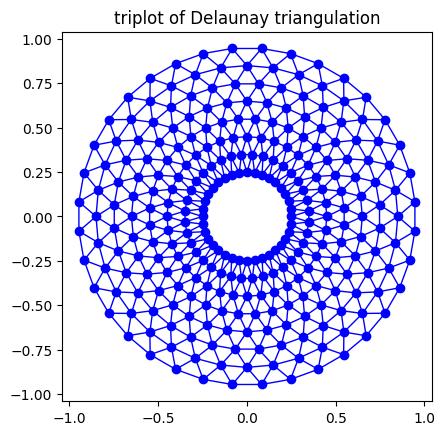

In [37]:
# First create the x and y coordinates of the points.
n_angles = 36
n_radii = 8
min_radius = 0.25
radii = np.linspace(min_radius, 0.95, n_radii)

angles = np.linspace(0, 2 * np.pi, n_angles, endpoint=False)
angles = np.repeat(angles[..., np.newaxis], n_radii, axis=1)
angles[:, 1::2] += np.pi / n_angles

x = (radii * np.cos(angles)).flatten()
y = (radii * np.sin(angles)).flatten()

# Create the Triangulation; no triangles so Delaunay triangulation created.
triang = tri.Triangulation(x, y)

# Mask off unwanted triangles.
triang.set_mask(np.hypot(x[triang.triangles].mean(axis=1),
                         y[triang.triangles].mean(axis=1))
                < min_radius)

fig1, ax1 = plt.subplots()
ax1.set_aspect('equal')
ax1.triplot(triang, 'bo-', lw=1)
ax1.set_title('triplot of Delaunay triangulation')

https://matplotlib.org/stable/gallery/images_contours_and_fields/triplot_demo.html

You can specify your own triangulation rather than perform a Delaunay triangulation of the points, where each triangle is given by the indices of the three points that make up the triangle, ordered in either a clockwise or anticlockwise manner.

In [40]:
xy = np.asarray([
    [-0.101, 0.872], [-0.080, 0.883], [-0.069, 0.888], [-0.054, 0.890],
    [-0.045, 0.897], [-0.057, 0.895], [-0.073, 0.900], [-0.087, 0.898],
    [-0.090, 0.904], [-0.069, 0.907], [-0.069, 0.921], [-0.080, 0.919],
    [-0.073, 0.928], [-0.052, 0.930], [-0.048, 0.942], [-0.062, 0.949],
    [-0.054, 0.958], [-0.069, 0.954], [-0.087, 0.952], [-0.087, 0.959],
    [-0.080, 0.966], [-0.085, 0.973], [-0.087, 0.965], [-0.097, 0.965],
    [-0.097, 0.975], [-0.092, 0.984], [-0.101, 0.980], [-0.108, 0.980],
    [-0.104, 0.987], [-0.102, 0.993], [-0.115, 1.001], [-0.099, 0.996],
    [-0.101, 1.007], [-0.090, 1.010], [-0.087, 1.021], [-0.069, 1.021],
    [-0.052, 1.022], [-0.052, 1.017], [-0.069, 1.010], [-0.064, 1.005],
    [-0.048, 1.005], [-0.031, 1.005], [-0.031, 0.996], [-0.040, 0.987],
    [-0.045, 0.980], [-0.052, 0.975], [-0.040, 0.973], [-0.026, 0.968],
    [-0.020, 0.954], [-0.006, 0.947], [ 0.003, 0.935], [ 0.006, 0.926],
    [ 0.005, 0.921], [ 0.022, 0.923], [ 0.033, 0.912], [ 0.029, 0.905],
    [ 0.017, 0.900], [ 0.012, 0.895], [ 0.027, 0.893], [ 0.019, 0.886],
    [ 0.001, 0.883], [-0.012, 0.884], [-0.029, 0.883], [-0.038, 0.879],
    [-0.057, 0.881], [-0.062, 0.876], [-0.078, 0.876], [-0.087, 0.872],
    [-0.030, 0.907], [-0.007, 0.905], [-0.057, 0.916], [-0.025, 0.933],
    [-0.077, 0.990], [-0.059, 0.993]])
x = np.degrees(xy[:, 0])
y = np.degrees(xy[:, 1])

triangles = np.asarray([
    [67, 66,  1], [65,  2, 66], [ 1, 66,  2], [64,  2, 65], [63,  3, 64],
    [60, 59, 57], [ 2, 64,  3], [ 3, 63,  4], [ 0, 67,  1], [62,  4, 63],
    [57, 59, 56], [59, 58, 56], [61, 60, 69], [57, 69, 60], [ 4, 62, 68],
    [ 6,  5,  9], [61, 68, 62], [69, 68, 61], [ 9,  5, 70], [ 6,  8,  7],
    [ 4, 70,  5], [ 8,  6,  9], [56, 69, 57], [69, 56, 52], [70, 10,  9],
    [54, 53, 55], [56, 55, 53], [68, 70,  4], [52, 56, 53], [11, 10, 12],
    [69, 71, 68], [68, 13, 70], [10, 70, 13], [51, 50, 52], [13, 68, 71],
    [52, 71, 69], [12, 10, 13], [71, 52, 50], [71, 14, 13], [50, 49, 71],
    [49, 48, 71], [14, 16, 15], [14, 71, 48], [17, 19, 18], [17, 20, 19],
    [48, 16, 14], [48, 47, 16], [47, 46, 16], [16, 46, 45], [23, 22, 24],
    [21, 24, 22], [17, 16, 45], [20, 17, 45], [21, 25, 24], [27, 26, 28],
    [20, 72, 21], [25, 21, 72], [45, 72, 20], [25, 28, 26], [44, 73, 45],
    [72, 45, 73], [28, 25, 29], [29, 25, 31], [43, 73, 44], [73, 43, 40],
    [72, 73, 39], [72, 31, 25], [42, 40, 43], [31, 30, 29], [39, 73, 40],
    [42, 41, 40], [72, 33, 31], [32, 31, 33], [39, 38, 72], [33, 72, 38],
    [33, 38, 34], [37, 35, 38], [34, 38, 35], [35, 37, 36]])

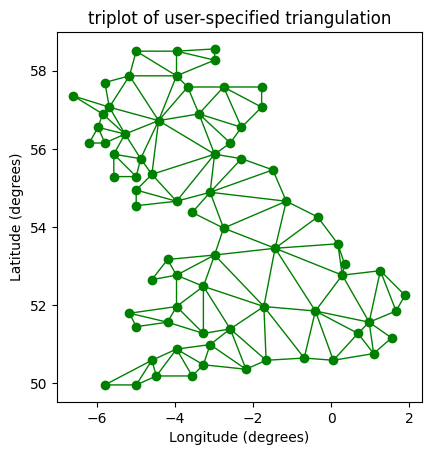

In [41]:
fig2, ax2 = plt.subplots()
ax2.set_aspect('equal')
ax2.triplot(x, y, triangles, 'go-', lw=1.0)
ax2.set_title('triplot of user-specified triangulation')
ax2.set_xlabel('Longitude (degrees)')
ax2.set_ylabel('Latitude (degrees)')

plt.show()